# Passo 6: Desconstruindo a Rede Neural (MediaPipe)

Excelente escolha! O **MediaPipe** não é apenas "uma" rede neural, ele é uma arquitetura genial chamada **Pipeline de ML (Machine Learning)**.

Para rastrear mãos em tempo real até em celulares fracos, o Google dividiu o problema em duas Redes Neurais separadas:
1. **Palm Detector (Detector de Palma):** Uma rede muito leve que não tenta achar dedos. Ela só tenta achar um "quadrado" onde está o centro da mão na tela inteira.
2. **Hand Landmark Model (Modelo de Marcos):** Essa é a rede neural principal. Ela não olha pra tela inteira! Ela recebe apenas o "quadradinho" cortado pela rede 1 e, dentro dele, calcula as coordenadas matemáticas de **21 pontos (juntas)**.

Nos notebooks anteriores nós usamos a função `draw_landmarks` que desenhava a teia automaticamente. Agora, nós vamos **ignorar essa função**, vamos extrair os dados puros do cérebro da IA e criar o nosso próprio reconhecedor de gestos usando matemática!

In [4]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import math

RTSP_URL = 'rtsp://admin:@Jeff2712@10.64.0.61:554/'

# Inicializamos apenas o cérebro das Mãos
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.5)

print("Capturando 1 frame da câmera...")
cap = cv2.VideoCapture(RTSP_URL)
# Vamos ler alguns frames (descartar os primeiros que às vezes vêm escuros)
for _ in range(10):
    ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
print("Frame capturado!")

Capturando 1 frame da câmera...
Frame capturado!


### Como a IA devolve o resultado?
A IA não cospe uma imagem desenhada. Ela devolve um arquivo cheio de números. 
Estes números são **X** (horizontal), **Y** (vertical) e **Z** (profundidade - sim, ela estima 3D!).

A ponta do dedo indicador, por exemplo, é o ponto de número **8** na arquitetura da rede.

In [5]:
resultado = hands.process(frame_rgb)

if resultado.multi_hand_landmarks:
    # Pegamos a primeira mão que ele achou
    primeira_mao = resultado.multi_hand_landmarks[0]
    
    # Extraindo a ponta do Dedo Indicador (Landmark 8)
    ponta_indicador = primeira_mao.landmark[mp_hands.HandLandmark.INDEX_FINGER_TIP]
    
    print("DADOS CRUS DA IA PARA A PONTA DO INDICADOR:")
    print(ponta_indicador)
    print("\nNote que X e Y são valores entre 0.0 e 1.0 (Porcentagem da tela).")
else:
    print("A IA não encontrou nenhuma mão nesta foto. Rode novamente com a mão na frente!")

DADOS CRUS DA IA PARA A PONTA DO INDICADOR:
x: 0.4409489035606384
y: 0.5174610614776611
z: -0.0740814283490181


Note que X e Y são valores entre 0.0 e 1.0 (Porcentagem da tela).


### Convertendo de IA para Pixels Reais e Criando um Gesto (Pinça)
Como X e Y são porcentagens (ex: `0.5` significa meio da tela), para descobrir o pixel exato nós multiplicamos pela Largura e Altura da imagem.

Vamos fazer um código que:
1. Pega a ponta do Polegar (Ponto 4) e a ponta do Indicador (Ponto 8).
2. Transforma em Pixels da nossa matriz.
3. Usa a famosa matemática do Teorema de Pitágoras para calcular a distância entre esses dois dedos.
4. Se a distância for pequena, detectamos o **Gesto de Pinça (Clique)**!

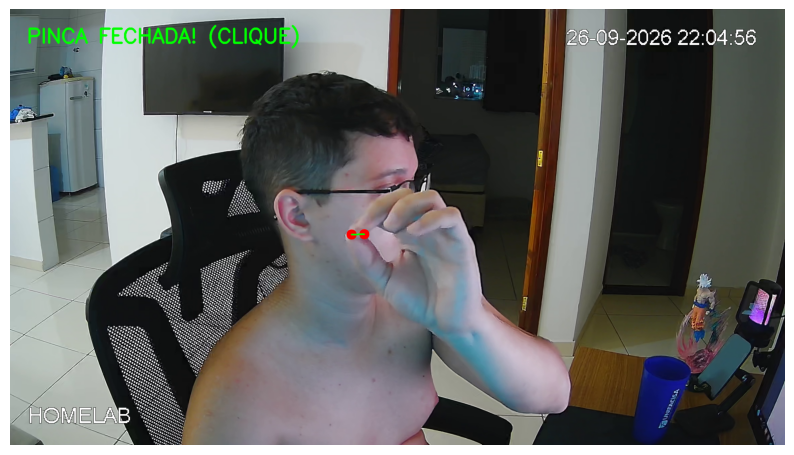

Distância matemática calculada: 38.01 pixels


In [6]:
if resultado.multi_hand_landmarks:
    # Altura e Largura da imagem atual
    h, w, canais = frame_rgb.shape
    
    # Coordenadas do Polegar (Ponto 4)
    polegar = primeira_mao.landmark[4]
    pixel_polegar_x = int(polegar.x * w)
    pixel_polegar_y = int(polegar.y * h)
    
    # Coordenadas do Indicador (Ponto 8)
    indicador = primeira_mao.landmark[8]
    pixel_indicador_x = int(indicador.x * w)
    pixel_indicador_y = int(indicador.y * h)

    # Calculando a distância (Matemática pura)
    distancia = math.hypot(pixel_indicador_x - pixel_polegar_x, pixel_indicador_y - pixel_polegar_y)
    
    # --- DESENHANDO NA MATRIZ MANUALMENTE ---
    # Desenhamos círculos sólidos nos dois dedos (Espessura -1)
    cv2.circle(frame_rgb, (pixel_polegar_x, pixel_polegar_y), 15, (255, 0, 0), -1) # Vermelho
    cv2.circle(frame_rgb, (pixel_indicador_x, pixel_indicador_y), 15, (255, 0, 0), -1) # Vermelho
    
    # Desenhamos uma linha conectando eles
    cv2.line(frame_rgb, (pixel_polegar_x, pixel_polegar_y), (pixel_indicador_x, pixel_indicador_y), (0, 255, 0), 3)
    
    # Logica do Gesto
    if distancia < 50:
        texto_gesto = "PINCA FECHADA! (CLIQUE)"
        cor = (0, 255, 0) # Verde
    else:
        texto_gesto = "MAO ABERTA"
        cor = (255, 0, 0) # Vermelho
        
    # Escrevendo o texto na tela
    cv2.putText(frame_rgb, texto_gesto, (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 2, cor, 5)
    
    plt.figure(figsize=(10,8))
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()
    print(f"Distância matemática calculada: {distancia:.2f} pixels")
else:
    print("Nenhuma mão encontrada na imagem. Tente rodar o bloco inteiro de novo com a mão na câmera!")